In [ ]:
# Time Series Forecasting Assignment (Custom RNN)
# Roll Number: 102317244

In [ ]:
# =========================
# 1. Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [ ]:
# =========================
# 2. Parameters (Derived)
# =========================
window_size = 12
prediction_horizon = 3
hidden_size = 14



In [ ]:
# =========================
# 3. Load Dataset (Example: AirPassengers)
# =========================
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv")
series = df['Passengers'].values.astype(float)

# Normalize
mean = series.mean()
std = series.std()
series = (series - mean) / std

print(mean)
print(std)
print(series)

280.2986111111111
119.54904153277147
[-1.40777884 -1.35759023 -1.24048348 -1.26557778 -1.33249593 -1.21538918
 -1.10664719 -1.10664719 -1.20702441 -1.34922546 -1.47469699 -1.35759023
 -1.38268454 -1.29067209 -1.16520057 -1.21538918 -1.29903686 -1.09828242
 -0.9226223  -0.9226223  -1.02299951 -1.23211871 -1.3910493  -1.17356534
 -1.1317415  -1.08991766 -0.85570415 -0.98117567 -0.90589276 -0.85570415
 -0.68004402 -0.68004402 -0.80551554 -0.98954044 -1.12337673 -0.95608137
 -0.91425753 -0.83897462 -0.73023263 -0.83060985 -0.81388031 -0.52111343
 -0.42073621 -0.320359   -0.59639634 -0.74696217 -0.90589276 -0.72186786
 -0.70513833 -0.70513833 -0.37054761 -0.37891237 -0.42910098 -0.31199423
 -0.1363341  -0.06941596 -0.36218284 -0.57966681 -0.83897462 -0.66331449
 -0.63822018 -0.77205647 -0.37891237 -0.44583052 -0.38727714 -0.1363341
  0.18152708  0.10624417 -0.17815794 -0.42910098 -0.64658495 -0.42910098
 -0.320359   -0.39564191 -0.1112398  -0.09451026 -0.08614549  0.29026907
  0.7001427   0

In [ ]:
# =========================
# 4. Create Windows
# =========================
def create_windows(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

X, y = create_windows(series, window_size, prediction_horizon)

# Train-test split (chronological)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# =========================
# 5. MLP Baseline
# =========================
class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP(window_size, prediction_horizon)


In [ ]:
# =========================
# 6. Custom RNN
# =========================

import torch.nn as nn

class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wx = nn.Linear(input_size, hidden_size)
        self.Wh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h = torch.zeros(x.size(0), self.hidden_size, device=x.device)
        for t in range(x.size(1)):
            xt = x[:, t]  # Corrected: Removed .unsqueeze(1)
            h = torch.tanh(self.Wx(xt) + self.Wh(h))
        return self.fc(h)

rnn = CustomRNN(1, hidden_size, prediction_horizon)

In [ ]:
# =========================
# 7. Training Function
# =========================
def train(model, X, y, epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        if isinstance(model, CustomRNN):
            preds = model(X.unsqueeze(-1))
        else:
            preds = model(X)

        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

# Train models
mlp_losses = train(mlp, X_train, y_train)
rnn_losses = train(rnn, X_train, y_train)

In [ ]:
# =========================
# 8. Evaluation
# =========================
def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        if isinstance(model, CustomRNN):
            preds = model(X.unsqueeze(-1))
        else:
            preds = model(X)

    preds = preds.numpy()
    y = y.numpy()

    mse = mean_squared_error(y, preds)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mse)

    return mse, mae, rmse, preds

mlp_metrics = evaluate(mlp, X_test, y_test)
rnn_metrics = evaluate(rnn, X_test, y_test)

print("MLP Metrics (MSE, MAE, RMSE):", mlp_metrics[:3])
print("RNN Metrics (MSE, MAE, RMSE):", rnn_metrics[:3])

MLP Metrics (MSE, MAE, RMSE): (0.11526423692703247, 0.2773561477661133, np.float64(0.3395058717121583))
RNN Metrics (MSE, MAE, RMSE): (0.5402827858924866, 0.5431138873100281, np.float64(0.7350393090797842))


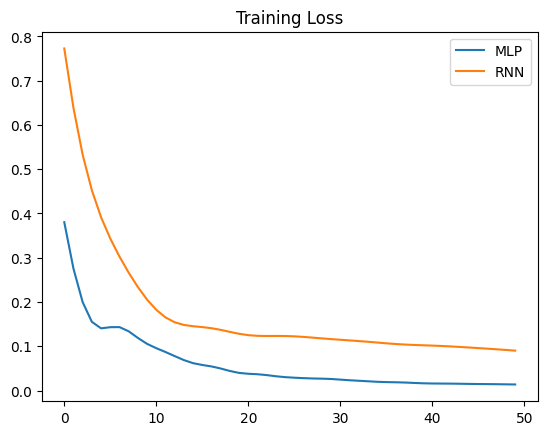

In [ ]:
# =========================
# 9. Plot Loss
# =========================
plt.plot(mlp_losses, label='MLP')
plt.plot(rnn_losses, label='RNN')
plt.legend()
plt.title("Training Loss")
plt.show()


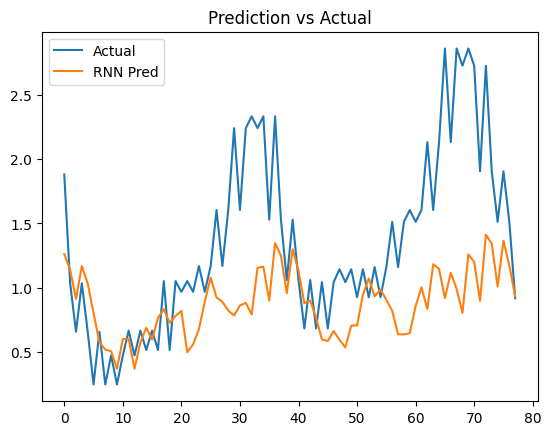

In [ ]:
# =========================
# 10. Prediction vs Actual
# =========================
plt.plot(y_test.numpy().flatten(), label='Actual')
plt.plot(rnn_metrics[3].flatten(), label='RNN Pred')
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

In [ ]:
# =========================
# 11. Second Dataset (Electricity - Example CSV Required)
# =========================
df2 = pd.read_csv("Electric_Production.csv")
series2 = df2.iloc[:,1].values.astype(float)

series2 = (series2 - series2.mean()) / series2.std()
X2, y2 = create_windows(series2, window_size, prediction_horizon)
split2 = int(0.8 * len(X2))
X2_train, X2_test = X2[:split2], X2[split2:]
y2_train, y2_test = y2[:split2], y2[split2:]

X2_train = torch.tensor(X2_train, dtype=torch.float32)
y2_train = torch.tensor(y2_train, dtype=torch.float32)
X2_test = torch.tensor(X2_test, dtype=torch.float32)
y2_test = torch.tensor(y2_test, dtype=torch.float32)

rnn2 = CustomRNN(1, hidden_size, prediction_horizon)
train(rnn2, X2_train, y2_train)

rnn2_metrics = evaluate(rnn2, X2_test, y2_test)
print("Electricity:", rnn2_metrics[:3])

Electricity: (0.235110804438591, 0.38575348258018494, np.float64(0.4848822583252464))


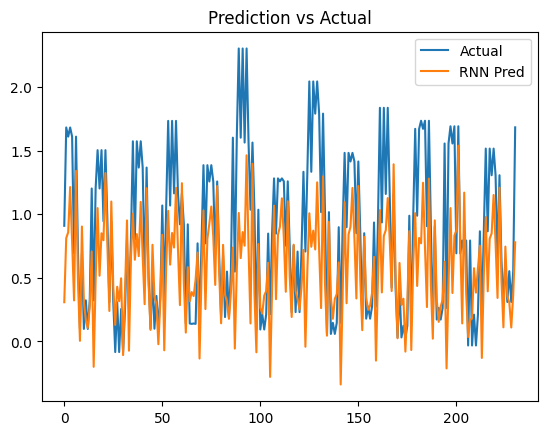

In [ ]:
plt.plot(y2_test.numpy().flatten(), label='Actual')
plt.plot(rnn2_metrics[3].flatten(), label='RNN Pred')
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

In [ ]:
# =========================
# 12. Ablation Study
# =========================
for ws in [window_size//2, window_size, window_size*2]:
    X_tmp, y_tmp = create_windows(series, ws, prediction_horizon)
    split = int(0.8 * len(X_tmp))
    Xtr, Xte = X_tmp[:split], X_tmp[split:]
    ytr, yte = y_tmp[:split], y_tmp[split:]

    Xtr = torch.tensor(Xtr, dtype=torch.float32)
    ytr = torch.tensor(ytr, dtype=torch.float32)
    Xte = torch.tensor(Xte, dtype=torch.float32)
    yte = torch.tensor(yte, dtype=torch.float32)

    model = CustomRNN(1, hidden_size, prediction_horizon)
    train(model, Xtr, ytr, epochs=30)
    metrics = evaluate(model, Xte, yte)

    print(f"Window Size {ws} -> RMSE: {metrics[2]}")

print("Done ✅")


Window Size 6 -> RMSE: 0.8524808918441942
Window Size 12 -> RMSE: 0.6540745599457769
Window Size 24 -> RMSE: 0.7800034305301445
Done ✅
